<a href="https://colab.research.google.com/github/J3ssye/ClientServerBasics-2.0/blob/main/Notebook_1_Node_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **SIBGRAPI 2026 – 39th Conference on Graphics, Patterns and Images**

### **Tutorial: An Introduction to Graph Neural Networks in Computer Vision: A Practical Perspective**

**Notebook 1: Applying a GNN to Node Classification on a Graph**

Barbara Caroline Benato, Lucas Pascotti Valem, Gabriel Maia Brito, Ian de Holanda Cavalcanti Bezerra, Rafael Mendonça Duarte, and Luis Gustavo Nonato

Institute of Mathematics and Computer Science (ICMC), University of São Paulo (USP), São Carlos, Brazil

Contact: Lucas Pascotti Valem (lucas@icmc.usp.br)

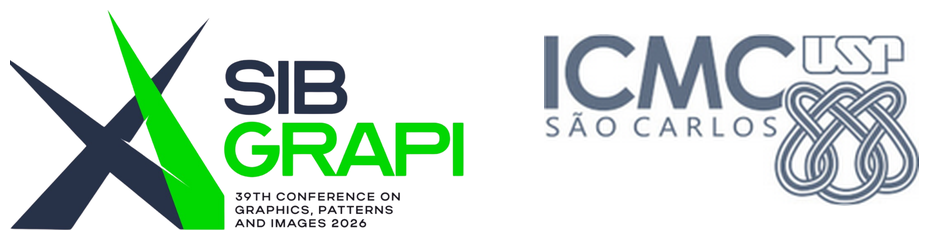

## **Goals of this Notebook:**
**This notebook provides a first hands-on introduction to Graph Neural Networks (GNNs).**

It covers the following steps:
* Installing the required dependencies, such as PyTorch and PyTorch Geometric;
* Defining a GNN model;
* Loading a dataset that already includes the input graph structure;
* Training and prediction for a node classification task;
* Presenting some visualizations.

## **Activities:**

**a.** Run the notebook.

**b.** Run it again with a different GNN model and try others, such as **SGC** and **GAT**.
Which model performs best?

**c.** Try implementing your own architecture by combining convolutions from different models.

**d.** Try a different dataset and visualize the resulting graph.




---



**1. Installing PyTorch Geometric**

In [ ]:
# Install PyTorch Geometric (PyG)
# Colab already ships with PyTorch (with CUDA), so we do NOT reinstall torch here.
# Since PyG 2.3, the optional extensions (torch-scatter, torch-sparse, torch-cluster,
# torch-spline-conv) are not needed for the layers used in this notebook,
# so this takes only a few seconds and does not require restarting the runtime.
!pip install -q torch-geometric

import torch
import torch_geometric
print("PyTorch:", torch.__version__)
print("PyG:", torch_geometric.__version__)
print("GPU available:", torch.cuda.is_available())

PyTorch: 2.11.0+cpu
PyG: 2.8.0.post1
GPU available: False


**2. Installing Visualization Libraries**

In [ ]:
!pip install networkx matplotlib

**3. Importing Libraries**

In [ ]:
# Torch and Torch Geometric
import torch
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv, ARMAConv
from torch.nn import Linear

In [ ]:
# For plotting charts and graphs
import matplotlib.pyplot as plt
import networkx as nx

**4. Loading the Dataset**

In [ ]:
# Cora:
# - Type: Citation network.
# - Nodes: 2,708 scientific papers.
# - Edges: 5,429 citation links.
# - Features: Each node has 1,433 attributes (bag-of-words).
# - Classes: 7 topic categories.
#dataset = Planetoid(root='/tmp/Cora', name='Cora')

# CiteSeer:
# - Type: Citation network.
# - Nodes: 3,327 scientific papers.
# - Edges: 4,732 citation links.
# - Features: Each node has 3,703 attributes (bag-of-words).
# - Classes: 6 topic categories.
#dataset = Planetoid(root='/tmp/CiteSeer', name='CiteSeer')

# PubMed:
# - Type: Citation network.
# - Nodes: 19,717 medical papers.
# - Edges: 44,338 citation links.
# - Features: Each node has 500 attributes (TF-IDF).
# - Classes: 3 disease categories.
dataset = Planetoid(root='/tmp/PubMed', name='PubMed')

**5. Defining the GNN Models**

In [ ]:
import torch
import torch.nn as nn

class SimpleGCNConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.weight = nn.Parameter(
            torch.randn(in_channels, out_channels) * 0.01
        )

    def forward(self, x, edge_index):
        """
        x: [N, F_in]
        edge_index: [2, E] in PyG format (src, dst)
        Implements: H' = Â H W, with symmetric normalization
        """
        num_nodes = x.size(0)
        device = x.device
        src, dst = edge_index  # src: source node, dst: target node

        # 1) Add self-loops
        self_loops = torch.arange(num_nodes, device=device)
        src = torch.cat([src, self_loops], dim=0)
        dst = torch.cat([dst, self_loops], dim=0)

        # 2) Compute degrees: deg[i] = number of neighbors (including self-loop)
        deg = torch.zeros(num_nodes, device=device, dtype=x.dtype)
        deg.index_add_(0, dst, torch.ones_like(dst, dtype=x.dtype))

        deg_inv_sqrt = deg.pow(-0.5)
        deg_inv_sqrt[torch.isinf(deg_inv_sqrt)] = 0.0

        # 3) Per-edge normalization factor
        #    norm[e] = 1 / sqrt(deg[src[e]] * deg[dst[e]])
        norm = deg_inv_sqrt[dst] * deg_inv_sqrt[src]  # [E]

        # 4) Apply weights W
        h = x @ self.weight  # [N, F_out]

        # 5) Aggregation: for each edge j → i, add norm * h_j to i
        out = torch.zeros(num_nodes, self.weight.size(1), device=device, dtype=x.dtype)
        # out[i] += norm[e] * h[src[e]]
        out.index_add_(0, dst, norm.unsqueeze(-1) * h[src])

        return out

In [ ]:
class GCN(torch.nn.Module):
    def __init__(self, num_features, num_classes, neurons=16):
        super(GCN, self).__init__()
        self.conv1 = SimpleGCNConv(num_features, neurons)
        self.conv2 = SimpleGCNConv(neurons, num_classes)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, training=self.training, p=0.5)
        x = self.conv2(x, edge_index)

        return F.log_softmax(x, dim=1)

In [ ]:
class GCN3Layer(torch.nn.Module):
    def __init__(self, num_features, num_classes, neurons=16):
        super(GCN3Layer, self).__init__()
        self.conv1 = GCNConv(num_features, neurons)
        self.conv2 = GCNConv(neurons, neurons)
        self.conv3 = GCNConv(neurons, num_classes)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        #x = self.conv1(x, edge_index).elu()
        x = F.elu(self.conv1(x, edge_index))
        x = self.conv2(x, edge_index).relu()
        x = self.conv3(x, edge_index)

        return F.log_softmax(x, dim=1)

In [ ]:
class ARMA(torch.nn.Module):
    def __init__(self, num_features, num_classes):
        super(ARMA, self).__init__()

        # First ARMAConv layer
        self.conv1 = ARMAConv(
            in_channels=num_features,
            out_channels=16,
            num_stacks=3,
            num_layers=2,
            shared_weights=True,
            dropout=0.25
        )

        # Second ARMAConv layer
        self.conv2 = ARMAConv(
            in_channels=16,
            out_channels=num_classes,
            num_stacks=3,
            num_layers=2,
            shared_weights=True,
            dropout=0.25,
            act=lambda x: x  # Identity activation function
        )

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        # Apply dropout and the first layer
        x = F.dropout(x, training=self.training)
        x = F.relu(self.conv1(x, edge_index))

        # Apply dropout again and the second layer
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index)

        # Return log_softmax for classification
        return F.log_softmax(x, dim=1)

In [ ]:
from torch_geometric.nn import APPNP

class APPNPNet(torch.nn.Module):
    def __init__(self, num_features, num_classes):
        super(APPNPNet, self).__init__()

        # Network hyperparameters
        hidden = 64  # Number of neurons in the hidden layer
        K = 10       # Number of propagation iterations
        alpha = 0.1  # Teleport factor

        # Linear layers
        self.lin1 = Linear(num_features, hidden)
        self.lin2 = Linear(hidden, num_classes)

        # APPNP layer
        self.prop1 = APPNP(K, alpha)

    def reset_parameters(self):
        """Reset the layer parameters."""
        self.lin1.reset_parameters()
        self.lin2.reset_parameters()

    def forward(self, data):
        dropout = 0.5  # Dropout rate
        x, edge_index = data.x, data.edge_index

        # Step 1: Initial dropout
        x = F.dropout(x, p=dropout, training=self.training)

        # Step 2: First linear layer with ReLU
        x = F.relu(self.lin1(x))

        # Step 3: Additional dropout
        x = F.dropout(x, p=dropout, training=self.training)

        # Step 4: Second linear layer
        x = self.lin2(x)

        # Step 5: Propagation using APPNP
        x = self.prop1(x, edge_index)

        # Step 6: Log softmax for classification
        return F.log_softmax(x, dim=1)

In [ ]:
from torch_geometric.nn import SGConv

class SGC(torch.nn.Module):
    def __init__(self, num_features, num_classes):
        super(SGC, self).__init__()

        # SGConv layer
        self.conv1 = SGConv(
            in_channels=num_features,
            out_channels=num_classes,
            K=2,         # Number of hops
            cached=True  # Cache for static graphs
        )

    def forward(self, data):
        """
        Main forward pass with softmax for classification tasks.
        """
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        return F.log_softmax(x, dim=1)

In [ ]:
class SimpleGATConv(nn.Module):
    def __init__(self, in_channels, out_channels,
                 heads=1, concat=True, dropout=0.0, negative_slope=0.2):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.heads = heads
        self.concat = concat
        self.dropout = dropout

        # Linear projection: X -> H (with heads)
        self.lin = nn.Linear(in_channels, heads * out_channels, bias=False)

        # Attention vectors: a_src, a_dst for each head
        self.att_src = nn.Parameter(torch.empty(heads, out_channels))
        self.att_dst = nn.Parameter(torch.empty(heads, out_channels))

        self.leakyrelu = nn.LeakyReLU(negative_slope)

        self.reset_parameters()

    def reset_parameters(self):
        nn.init.xavier_uniform_(self.lin.weight)
        nn.init.xavier_uniform_(self.att_src)
        nn.init.xavier_uniform_(self.att_dst)

    def forward(self, x, edge_index):
        """
        x: [N, F_in]
        edge_index: [2, E] (src, dst) in PyG format
        output:
            if concat=True: [N, heads * out_channels]
            if concat=False: [N, out_channels] (mean over heads)
        """
        N = x.size(0)
        device = x.device

        src, dst = edge_index  # [E], [E]

        # 1) Add self-loops
        loop = torch.arange(N, device=device)
        src = torch.cat([src, loop], dim=0)
        dst = torch.cat([dst, loop], dim=0)

        # 2) Linear projection: X -> H
        #    h: [N, heads, out_channels]
        h = self.lin(x)                         # [N, heads * out_channels]
        h = h.view(N, self.heads, self.out_channels)

        # 3) Gather features at the edge endpoints
        h_src = h[src]                          # [E, heads, out_channels]
        h_dst = h[dst]                          # [E, heads, out_channels]

        # 4) Compute e_ij for each edge and head
        #    e_ij^k = LeakyReLU( <a_src^k, h_i^k> + <a_dst^k, h_j^k> )
        e = (h_src * self.att_src).sum(dim=-1)  # [E, heads]
        e += (h_dst * self.att_dst).sum(dim=-1) # [E, heads]
        e = self.leakyrelu(e)

        # 5) Softmax over the neighbors of each target node (dst)
        #    uses an exp + index_add trick (no Python loops)
        exp_e = torch.exp(e)                    # [E, heads]

        # denom[i, k] = sum_{j in N(i)} exp(e_ij^k)
        denom = torch.zeros(N, self.heads, device=device)
        denom.index_add_(0, dst, exp_e)         # sum per target node

        alpha = exp_e / (denom[dst] + 1e-16)    # [E, heads]

        # Dropout on the attention coefficients
        alpha = F.dropout(alpha, p=self.dropout, training=self.training)

        # 6) Aggregation: h'_i^k = sum_j alpha_ij^k * h_j^k
        out = torch.zeros(N, self.heads, self.out_channels, device=device)
        out.index_add_(0, dst, alpha.unsqueeze(-1) * h_src)  # [E, heads, out]

        # 7) Concatenate or average the heads
        if self.concat:
            out = out.reshape(N, self.heads * self.out_channels)
        else:
            out = out.mean(dim=1)               # [N, out_channels]

        return out

In [ ]:
from torch_geometric.nn import GATConv

class GAT(torch.nn.Module):
    def __init__(self, in_channels, out_channels):
        super(GAT, self).__init__()

        # First GATConv layer with multiple heads
        self.conv1 = SimpleGATConv(
            in_channels=in_channels,
            out_channels=8,  # Output size of each head
            heads=8,         # Number of attention heads
            dropout=0.6      # Dropout during attention computation
        )

        # Second GATConv layer with a single head
        # The number of input channels is 8 * 8 (first-layer outputs * heads)
        self.conv2 = SimpleGATConv(
            in_channels=8 * 8,
            out_channels=out_channels,
            dropout=0.6
        )

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        # Apply dropout to the input
        x = F.dropout(x, p=0.6, training=self.training)

        # First GATConv layer with ELU activation
        x = F.elu(self.conv1(x, edge_index))

        # Apply dropout after the first layer
        x = F.dropout(x, p=0.6, training=self.training)

        # Second GATConv layer
        x = self.conv2(x, edge_index)

        # Return log_softmax for classification
        return F.log_softmax(x, dim=1)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv

class GraphSAGE(torch.nn.Module):
    def __init__(self, num_features, num_classes, hidden_channels=16, dropout=0.5):
        super(GraphSAGE, self).__init__()

        self.conv1 = SAGEConv(num_features, hidden_channels)   # 1st GraphSAGE layer
        self.conv2 = SAGEConv(hidden_channels, num_classes)    # 2nd GraphSAGE layer

        self.dropout = dropout

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        # 1st layer + ReLU
        x = self.conv1(x, edge_index)
        x = F.relu(x)

        # Dropout (training mode only)
        x = F.dropout(x, p=self.dropout, training=self.training)

        # 2nd layer (no activation)
        x = self.conv2(x, edge_index)

        # Log-softmax for node classification
        return F.log_softmax(x, dim=1)

**6. Instantiating the Model and Preparing for Training**

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GCN(dataset.num_node_features, dataset.num_classes).to(device)  # model choice
data = dataset[0].to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

**7. Defining Visualization Functions**

In [ ]:
# Function to convert the data to NetworkX
def to_networkx(data):
    G = nx.Graph()
    for i in range(data.num_nodes):
        G.add_node(i)
    edge_index = data.edge_index.cpu().numpy()
    edges = zip(edge_index[0], edge_index[1])
    G.add_edges_from(edges)
    return G

In [ ]:
# Function to save the graph with predictions
def save_graph_predictions(model, data, G, epoch):
    _, pred = model(data).max(dim=1)
    colors = [f'C{color}' for color in pred.cpu().numpy()]
    plt.figure(figsize=(8, 8))
    nx.draw(G, node_color=colors, node_size=35, linewidths=0.5, width=0.5, edge_color="gray")
    plt.title(f'Graph Predictions at Epoch {epoch + 1}')
    plt.savefig(f'graph_predictions_epoch_{epoch + 1}.png')
    plt.close()

In [ ]:
# Function to save loss plots
def save_loss_plot(train_losses, val_losses, test_losses, epoch):
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.plot(test_losses, label='Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Losses over Epochs (up to epoch {epoch + 1})')
    plt.legend()
    plt.grid()
    plt.savefig(f'loss_plot_epoch_{epoch + 1}.png')
    plt.close()

In [ ]:
# Function to save accuracy plots
def save_accuracy_plot(val_accs, test_accs, train_accs, epoch):
    plt.figure()
    plt.plot(val_accs, label='Validation Accuracy')
    plt.plot(test_accs, label='Test Accuracy')
    plt.plot(train_accs, label='Train Accuracy')
    plt.title('Accuracy Plot')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid()
    plt.savefig(f'accuracy_epoch_{epoch}.png')
    plt.close()

**8. Defining Training Functions**

In [ ]:
data.train_mask

tensor([ True,  True,  True,  ..., False, False, False])

In [ ]:
data.test_mask

tensor([False, False, False,  ...,  True,  True,  True])

In [ ]:
data.val_mask

tensor([False, False, False,  ..., False, False, False])

In [ ]:
# Function to train the model for one epoch
def train_model(model, optimizer, data):
    model.train()
    optimizer.zero_grad()
    out = model(data)

    # Compute the loss
    train_loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])

    # Backpropagation
    train_loss.backward()
    optimizer.step()

    # Compute accuracy directly
    pred = out[data.train_mask].argmax(dim=1)  # Predictions
    correct = (pred == data.y[data.train_mask]).sum().item()  # Correct predictions
    acc_train = correct / data.train_mask.sum().item()  # Accuracy

    return train_loss.item(), acc_train

In [ ]:
import torch

# Function to evaluate the model
def evaluate_model(model, data):
    model.eval()
    with torch.no_grad():
        out = model(data)
        val_loss = F.nll_loss(out[data.val_mask], data.y[data.val_mask])
        test_loss = F.nll_loss(out[data.test_mask], data.y[data.test_mask])

        # Compute accuracies
        val_preds = out[data.val_mask].max(1)[1]  # Index of the class with the highest probability
        test_preds = out[data.test_mask].max(1)[1]
        val_acc = val_preds.eq(data.y[data.val_mask]).sum().item() / data.val_mask.sum().item()
        test_acc = test_preds.eq(data.y[data.test_mask]).sum().item() / data.test_mask.sum().item()

    return val_loss.item(), test_loss.item(), val_acc, test_acc

In [ ]:
# Main function to run the training
def main_training_loop(model, optimizer, data, num_epochs=200):
    G = to_networkx(data)  # Build the graph
    train_losses, val_losses, test_losses = [], [], []
    val_accs, test_accs, train_accs = [], [], []  # Accuracy lists

    for epoch in range(num_epochs):
        # Training
        train_loss, train_acc = train_model(model, optimizer, data)
        train_losses.append(train_loss)

        # Evaluation
        val_loss, test_loss, val_acc, test_acc = evaluate_model(model, data)
        val_losses.append(val_loss)
        test_losses.append(test_loss)
        val_accs.append(val_acc)
        test_accs.append(test_acc)
        train_accs.append(train_acc)

        if ((epoch+1) % 10 == 0):
            print(f'Epoch {epoch + 1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Test Loss: {test_loss:.4f}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}, Test Acc: {test_acc:.4f}')

    # Generate plots as .png
    print("Plotting graphs and saving to files...")
    save_loss_plot(train_losses, val_losses, test_losses, epoch)
    save_accuracy_plot(val_accs, test_accs, train_accs, epoch)  # Save the accuracy plot
    save_graph_predictions(model, data, G, epoch)

    print("Done!")

**9. Training**

In [ ]:
main_training_loop(model, optimizer, data, num_epochs=50)

Epoch 10, Train Loss: 1.5691, Val Loss: 1.7133, Test Loss: 1.7036, Train Acc: 0.5929, Val Acc: 0.3440, Test Acc: 0.3680
Epoch 20, Train Loss: 0.6949, Val Loss: 1.1424, Test Loss: 1.1059, Train Acc: 0.9500, Val Acc: 0.7220, Test Acc: 0.7300
Epoch 30, Train Loss: 0.2519, Val Loss: 0.8256, Test Loss: 0.7564, Train Acc: 0.9643, Val Acc: 0.7660, Test Acc: 0.7830
Epoch 40, Train Loss: 0.0980, Val Loss: 0.7857, Test Loss: 0.6977, Train Acc: 0.9929, Val Acc: 0.7600, Test Acc: 0.7780
Epoch 50, Train Loss: 0.0620, Val Loss: 0.7798, Test Loss: 0.6815, Train Acc: 1.0000, Val Acc: 0.7640, Test Acc: 0.7810
Plotting graphs and saving to files...
Done!


**10. Model Evaluation**

In [ ]:
model.eval()
_, pred = model(data).max(dim=1)
correct = int(pred[data.test_mask].eq(data.y[data.test_mask]).sum().item())
accuracy = correct / int(data.test_mask.sum())
print(f'Accuracy: {accuracy}')

Accuracy: 0.781


**11. Visualization: Training Progress and Graph**

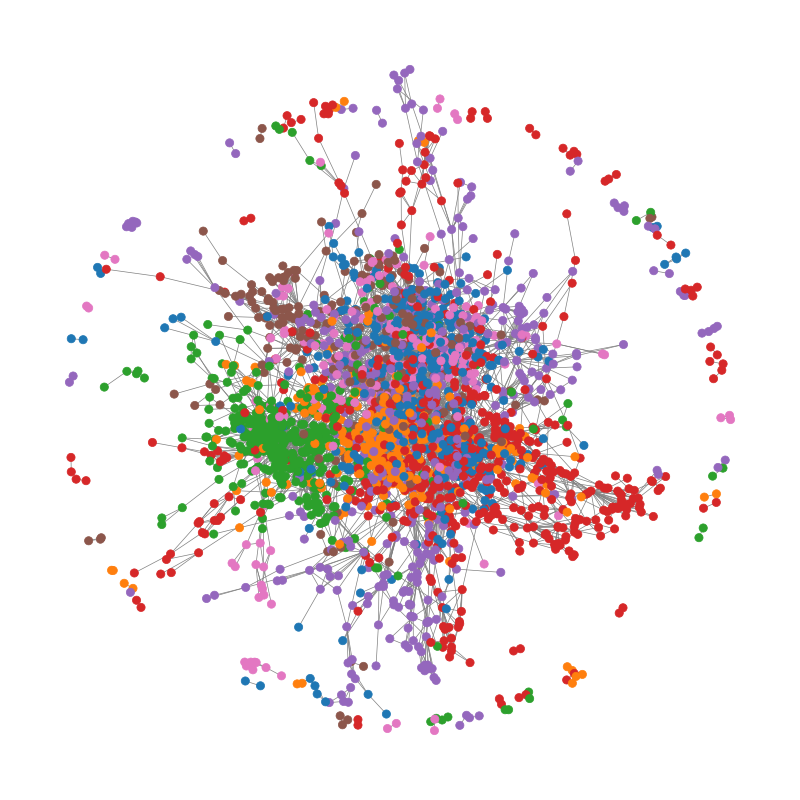

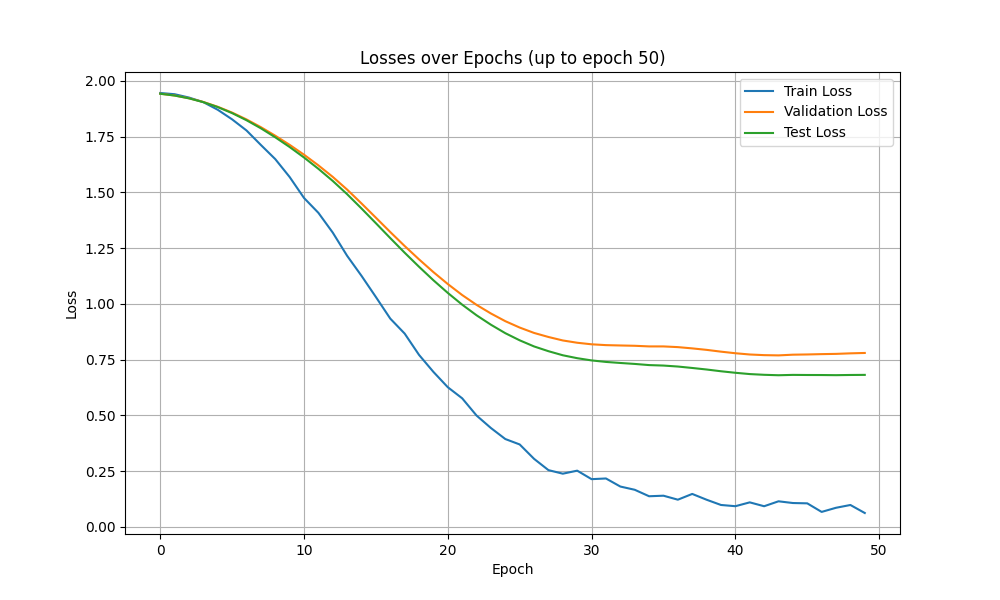

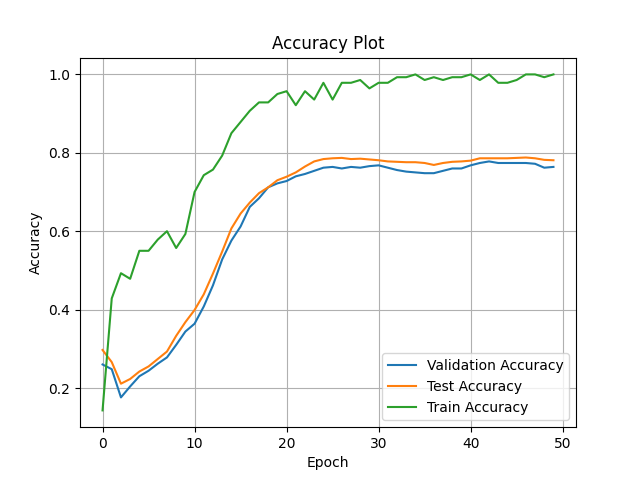

In [ ]:
import os
from IPython import display

image_width = 600

for x in os.listdir("."):
    if "graph_" in x:
        display.display(display.Image(x, width=image_width))

for x in os.listdir("."):
    if "loss_" in x:
        display.display(display.Image(x, width=image_width))

for x in os.listdir("."):
    if "accuracy_" in x:
        display.display(display.Image(x, width=image_width))

**12. Inductive Setting: Classifying Nodes Unseen During Training**

In [ ]:
import torch
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import SAGEConv

# 0. Optional reproducibility
# torch.manual_seed(42)

# 1. Load Cora
dataset = Planetoid(root='data/Cora', name='Cora')
data = dataset[0]

num_nodes = data.num_nodes

# 2. Split nodes into training nodes and unseen test nodes
perm = torch.randperm(num_nodes)

# 50% as unseen (inductive) test nodes
inductive_test_nodes = perm[: int(0.50 * num_nodes)]
train_nodes = perm[int(0.50 * num_nodes):]

# 3. Build the training subgraph with manual reindexing
# mapping[old_id] = new_id in {0, ..., num_train_nodes-1}
mapping = -torch.ones(num_nodes, dtype=torch.long)
mapping[train_nodes] = torch.arange(train_nodes.size(0))

row, col = data.edge_index

# keep only edges whose two endpoints are in train_nodes
mask = (mapping[row] >= 0) & (mapping[col] >= 0)
row_train = mapping[row[mask]]
col_train = mapping[col[mask]]
train_edge_index = torch.stack([row_train, col_train], dim=0)

# features and labels of training nodes only
x_train = data.x[train_nodes]
y_train = data.y[train_nodes]

# 4. Define the GraphSAGE model
class GraphSAGE(torch.nn.Module):
    def __init__(self, in_channels, hidden, out_channels):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden)
        self.conv2 = SAGEConv(hidden, out_channels)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = self.conv2(x, edge_index)
        return x

model = GraphSAGE(
    in_channels=dataset.num_features,
    hidden=64,
    out_channels=dataset.num_classes,
)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

# 5. Train strictly on the training subgraph
for epoch in range(200):
    model.train()
    optimizer.zero_grad()

    # Only sees x_train and train_edge_index, which contain training nodes only
    out_train = model(x_train, train_edge_index)
    loss = F.cross_entropy(out_train, y_train)

    loss.backward()
    optimizer.step()

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:03d}  Loss: {loss.item():.4f}")

# 6. Inductive test on the full graph
model.eval()
with torch.no_grad():
    # Here the model is applied to the full graph,
    # including the unseen nodes that never appeared during training
    logits_full = model(data.x, data.edge_index)
    pred_full = logits_full.argmax(dim=1)

# Accuracy on the unseen nodes only
acc = (pred_full[inductive_test_nodes] == data.y[inductive_test_nodes]).float().mean()
print("Inductive accuracy:", acc.item())


Epoch 050  Loss: 0.0190
Epoch 100  Loss: 0.0122
Epoch 150  Loss: 0.0099
Epoch 200  Loss: 0.0088
Inductive accuracy: 0.8530280590057373
